<a href="https://colab.research.google.com/github/AliJabbi/Auto-sales-data/blob/main/Copy_of_Ali_Jabbi_Auto_Sales_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
%matplotlib inline

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive//Auto Sales data.csv'

In [4]:
df = pd.read_csv(file_path, na_values=["", " ", "NA", "N/A", "--"])
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24/02/2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,07/05/2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,01/07/2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25/08/2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,28/10/2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2742,10350,20,112.22,15,2244.40,02/12/2019,2924,Shipped,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Small
2743,10373,29,137.19,1,3978.51,31/01/2020,2865,Shipped,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",981-443655,Torikatu 38,Oulu,90110,Finland,Koskitalo,Pirkko,Medium
2744,10386,43,125.99,4,5417.57,01/03/2020,2836,Resolved,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Medium
2745,10397,34,62.24,1,2116.16,28/03/2020,2810,Shipped,Ships,54,S72_3212,Alpha Cognac,61.77.6555,1 rue Alsace-Lorraine,Toulouse,31000,France,Roulet,Annette,Small


In [5]:
df = df.drop(columns=['PHONE'])
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24/02/2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,07/05/2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,01/07/2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25/08/2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,28/10/2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ORDERNUMBER           2747 non-null   int64  
 1   QUANTITYORDERED       2747 non-null   int64  
 2   PRICEEACH             2747 non-null   float64
 3   ORDERLINENUMBER       2747 non-null   int64  
 4   SALES                 2747 non-null   float64
 5   ORDERDATE             2747 non-null   object 
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64  
 7   STATUS                2747 non-null   object 
 8   PRODUCTLINE           2747 non-null   object 
 9   MSRP                  2747 non-null   int64  
 10  PRODUCTCODE           2747 non-null   object 
 11  CUSTOMERNAME          2747 non-null   object 
 12  ADDRESSLINE1          2747 non-null   object 
 13  CITY                  2747 non-null   object 
 14  POSTALCODE            2747 non-null   object 
 15  COUNTRY              

In [7]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

/tmp/ipython-input-2660003905.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ORDERNUMBER           2747 non-null   int64         
 1   QUANTITYORDERED       2747 non-null   int64         
 2   PRICEEACH             2747 non-null   float64       
 3   ORDERLINENUMBER       2747 non-null   int64         
 4   SALES                 2747 non-null   float64       
 5   ORDERDATE             2747 non-null   datetime64[ns]
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64         
 7   STATUS                2747 non-null   object        
 8   PRODUCTLINE           2747 non-null   object        
 9   MSRP                  2747 non-null   int64         
 10  PRODUCTCODE           2747 non-null   object        
 11  CUSTOMERNAME          2747 non-null   object        
 12  ADDRESSLINE1          2747 non-null   object        
 13  CITY              

In [9]:
df.isna().sum()

,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
DAYS_SINCE_LASTORDER,0
STATUS,0
PRODUCTLINE,0
MSRP,0


In [10]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,MSRP
count,2747.000000,2747.000000,2747.000000,2747.000000,2747.000000,2747,2747.000000,2747.000000
mean,10259.761558,35.103021,101.098952,6.491081,3553.047583,2019-05-13 21:56:17.211503360,1757.085912,100.691664
min,10100.000000,6.000000,26.880000,1.000000,482.130000,2018-01-06 00:00:00,42.000000,33.000000
25%,10181.000000,27.000000,68.745000,3.000000,2204.350000,2018-11-08 00:00:00,1077.000000,68.000000
50%,10264.000000,35.000000,95.550000,6.000000,3184.800000,2019-06-24 00:00:00,1761.000000,99.000000
75%,10334.500000,43.000000,127.100000,9.000000,4503.095000,2019-11-17 00:00:00,2436.500000,124.000000
max,10425.000000,97.000000,252.870000,18.000000,14082.800000,2020-05-31 00:00:00,3562.000000,214.000000
std,91.877521,9.762135,42.042549,4.230544,1838.953901,NaN,819.280576,40.114802


In [11]:
df.describe(include= "O")

,STATUS,PRODUCTLINE,PRODUCTCODE,CUSTOMERNAME,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
count,2747,2747,2747,2747,2747,2747,2747,2747,2747,2747,2747
unique,6,7,109,89,89,71,73,19,76,72,3
top,Shipped,Classic Cars,S18_3232,Euro Shopping Channel,"C/ Moralzarzal, 86",Madrid,28034,USA,Freyre,Diego,Medium
freq,2541,949,51,259,259,304,259,928,259,259,1349


In [12]:
df = df.drop_duplicates()

In [13]:
df.rename(columns={"MSRP": "SuggestedRetailPrice", "PRICEEACH": "ActualPrice"}, inplace=True)

In [14]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,ActualPrice,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,SuggestedRetailPrice,PRODUCTCODE,CUSTOMERNAME,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2018-02-24,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2018-05-07,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2018-07-01,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2018-08-25,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,2018-10-28,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


In [15]:
len(df)

2747

In [16]:
df["SALES"].max()

14082.8

In [17]:
df["SALES"].min()

482.13

Text(0, 0.5, 'Frequency')

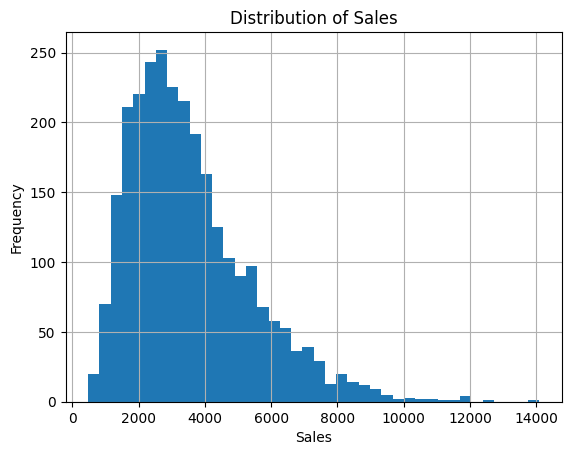

In [18]:
df["SALES"].hist(bins = 40)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

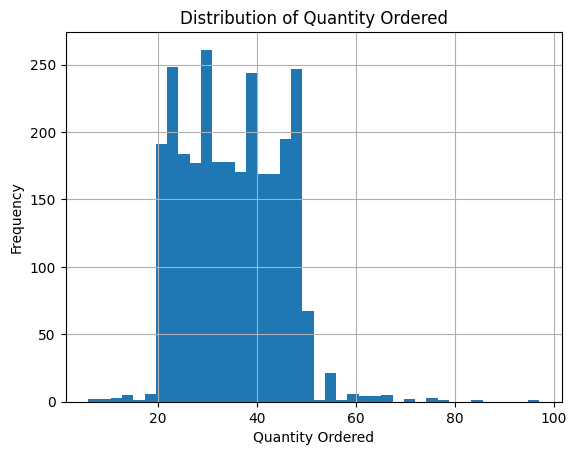

In [19]:
df["QUANTITYORDERED"].hist(bins = 40)
plt.title("Distribution of Quantity Ordered")
plt.xlabel("Quantity Ordered")
plt.ylabel("Frequency")

Text(0, 0.5, 'Number of Orders')

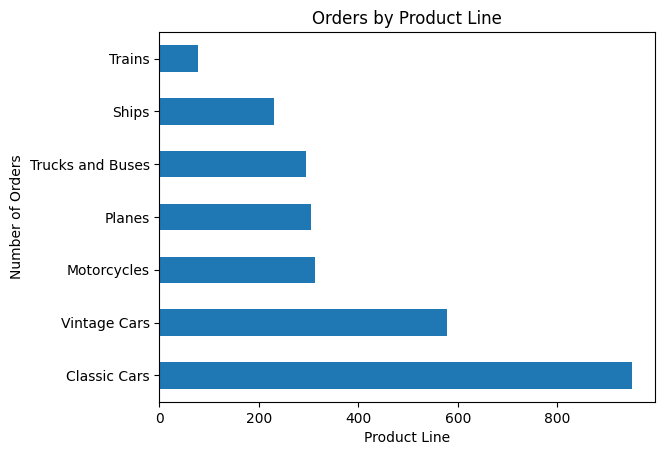

In [20]:
df["PRODUCTLINE"].value_counts().plot(kind = "barh")
plt.title("Orders by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Number of Orders")

Text(0, 0.5, 'Count')

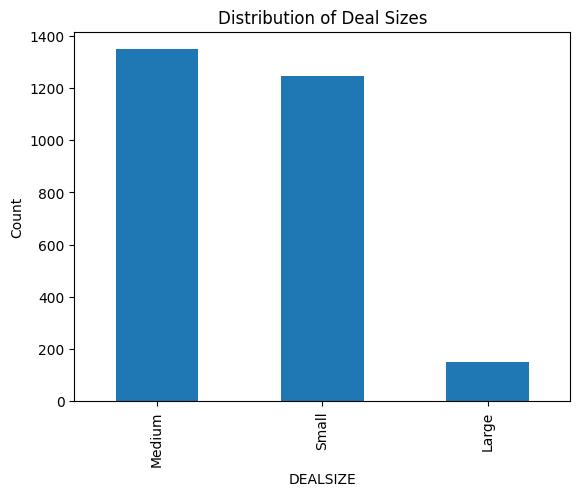

In [21]:
df["DEALSIZE"].value_counts().plot(kind = "bar")
plt.title("Distribution of Deal Sizes")
plt.xlabel("DEALSIZE")
plt.ylabel("Count")

Text(-12.430555555555555, 0.5, 'Sales')

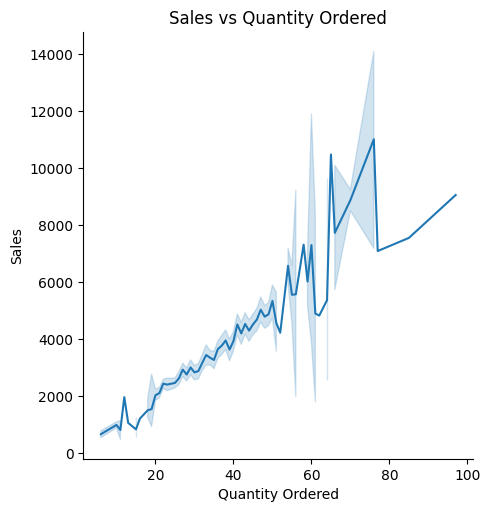

In [22]:
sns.relplot(x="QUANTITYORDERED", y="SALES", kind = "line", data=df)
plt.title("Sales vs Quantity Ordered")
plt.xlabel("Quantity Ordered")
plt.ylabel("Sales")

Text(5.069444444444445, 0.5, 'Actual Selling Price')

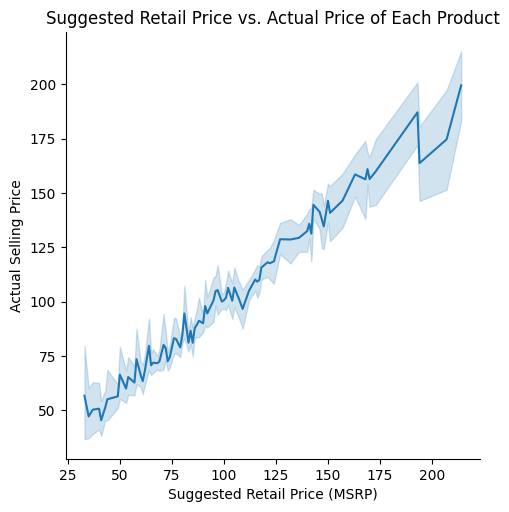

In [23]:
sns.relplot(x="SuggestedRetailPrice", y="ActualPrice", kind = "line", data=df)
plt.title("Suggested Retail Price vs. Actual Price of Each Product")
plt.xlabel("Suggested Retail Price (MSRP)")
plt.ylabel("Actual Selling Price")

# Machine Learning with Linear Regression and K-Nearest Neighbors

In [24]:
lm = smf.ols("SALES ~ QUANTITYORDERED + ActualPrice + SuggestedRetailPrice + DAYS_SINCE_LASTORDER" , df).fit()

lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  SALES   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                 1.318e+04
Date:                Fri, 19 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:18:10   Log-Likelihood:                -20416.
No. Observations:                2747   AIC:                         4.084e+04
Df Residuals:                    2742   BIC:                         4.087e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -3561.3056     47.628    -74.773      0.000   -3654.697   -3467.914
QUANTITYORDERED        102.6983      0.800    128.360      0.000     101.129     104.267
ActualPrice             35.2238      0.296    119.039      0.000      34.644      35.804
SuggestedRetailPrice    -0.2861      0.334     -0.856      0.392      -0.942       0.369
DAYS_SINCE_LASTORDER    -0.0131      0.011     -1.167      0.243      -0.035       0.009
==============================================================================
Omnibus:                      361.396   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3181.092
Skew:                           0.308   Prob(JB):                         0.00
Kurtosis:                       8.236   Cond. No.                     1.19e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.19e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [25]:
lm2 = smf.ols("SALES ~ QUANTITYORDERED + ActualPrice + DAYS_SINCE_LASTORDER" , df).fit()

lm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  SALES   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 1.758e+04
Date:                Fri, 19 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:23:12   Log-Likelihood:                -20416.
No. Observations:                2747   AIC:                         4.084e+04
Df Residuals:                    2743   BIC:                         4.086e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -3577.3815     43.766    -81.738      0.000   -3663.200   -3491.563
QUANTITYORDERED        102.6888      0.800    128.367      0.000     101.120     104.257
ActualPrice             35.0390      0.202    173.168      0.000      34.642      35.436
DAYS_SINCE_LASTORDER    -0.0095      0.010     -0.913      0.361      -0.030       0.011
==============================================================================
Omnibus:                      364.357   Durbin-Watson:                   1.966
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3198.207
Skew:                           0.317   Prob(JB):                         0.00
Kurtosis:                       8.248   Cond. No.                     1.09e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [26]:
import statsmodels.formula.api as smf

lm3 = smf.ols("SALES ~ QUANTITYORDERED + ActualPrice" , df).fit()

lm3.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  SALES   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 2.637e+04
Date:                Fri, 19 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:23:15   Log-Likelihood:                -20417.
No. Observations:                2747   AIC:                         4.084e+04
Df Residuals:                    2744   BIC:                         4.086e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -3601.9648     34.510   -104.375      0.000   -3669.633   -3534.297
QUANTITYORDERED   102.7030      0.800    128.413      0.000     101.135     104.271
ActualPrice        35.1124      0.186    189.073      0.000      34.748      35.477
==============================================================================
Omnibus:                      366.269   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3197.410
Skew:                           0.324   Prob(JB):                         0.00
Kurtosis:                       8.245   Cond. No.                         505.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#NOT using the model below anymore.

In [27]:
x = df[['QUANTITYORDERED', 'ActualPrice', 'SuggestedRetailPrice', 'DAYS_SINCE_LASTORDER']]
y = df['SALES']

In [28]:
x.head()

,QUANTITYORDERED,ActualPrice,SuggestedRetailPrice,DAYS_SINCE_LASTORDER
0,30,95.70,95,828
1,34,81.35,95,757
2,41,94.74,95,703
3,45,83.26,95,649
4,36,96.66,95,586


In [29]:
y.head()

,SALES
0,2871.00
1,2765.90
2,3884.34
3,3746.70
4,3479.76


In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

LinearRegression()

In [32]:
y_test_pred_lin = linear_model.predict(x_test)

In [33]:
mean_squared_error(y_test, y_test_pred_lin)

168912.78270096783

In [34]:
y_train_pred_lin = linear_model.predict(x_train)

In [35]:
mean_squared_error(y_train, y_train_pred_lin)

166731.60198287098

In [ ]:
#Using less variables

In [36]:
X = df[['QUANTITYORDERED', 'ActualPrice', 'DAYS_SINCE_LASTORDER']]
y = df['SALES']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
linear_model2 = LinearRegression()
linear_model2.fit(X_train, y_train)

LinearRegression()

In [39]:
y_test_pred_lin2 = linear_model2.predict(X_test)

In [40]:
mse2_test = mean_squared_error(y_test, y_test_pred_lin2)
mse2_test

168664.59651802876

In [41]:
y_train_pred_lin2 = linear_model2.predict(X_train)

In [42]:
mse2_train = mean_squared_error(y_train, y_train_pred_lin)
mse2_train

166731.60198287098

# K-Nearest Neighbors

In [52]:
mses = []
for k in range(1,21):
    print("Now computing MSE for k=",k)
    iknn_scaled = KNeighborsRegressor(n_neighbors = k)
    iknn_scaled.fit(x_train_scaled, y_train)
    iy_pred_scaled = iknn_scaled.predict(x_test_scaled)
    mse = mean_squared_error(iy_pred_scaled, y_test)
    mses.append(mse)

Now computing MSE for k= 1
Now computing MSE for k= 2
Now computing MSE for k= 3
Now computing MSE for k= 4
Now computing MSE for k= 5
Now computing MSE for k= 6
Now computing MSE for k= 7
Now computing MSE for k= 8
Now computing MSE for k= 9
Now computing MSE for k= 10
Now computing MSE for k= 11
Now computing MSE for k= 12
Now computing MSE for k= 13
Now computing MSE for k= 14
Now computing MSE for k= 15
Now computing MSE for k= 16
Now computing MSE for k= 17
Now computing MSE for k= 18
Now computing MSE for k= 19
Now computing MSE for k= 20


Text(0.5, 1.0, 'MSE for KNN Auto Sales Model')

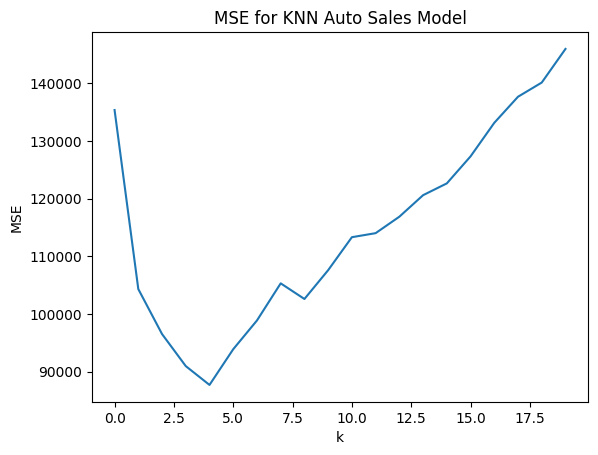

In [53]:
plt.plot(mses)
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("MSE for KNN Auto Sales Model")

In [46]:
X = df[['QUANTITYORDERED', 'ActualPrice', 'DAYS_SINCE_LASTORDER']]
y = df['SALES']

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [48]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [49]:
knn = KNeighborsRegressor(n_neighbors= 3)
knn.fit(x_train_scaled, y_train)

y_train_pred = knn.predict(x_train_scaled)
y_test_pred = knn.predict(x_test_scaled)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

In [50]:
mse_train

53714.335644879364

In [51]:
mse_test
# this one overfitted

96513.75489765657

In [ ]:
#Second one

In [54]:
knn = KNeighborsRegressor(n_neighbors= 5)
knn.fit(x_train_scaled, y_train)

y_train_pred = knn.predict(x_train_scaled)
y_test_pred = knn.predict(x_test_scaled)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

In [55]:
mse_train

80953.35797020298

In [56]:
mse_test

87685.34084564364

# Principal Component Analysis

In [58]:
pca_data = df[["SALES", "QUANTITYORDERED", "ActualPrice", "SuggestedRetailPrice", "DAYS_SINCE_LASTORDER"]].dropna()

In [61]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

In [62]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])

In [80]:
pca_df["DEALSIZE"] = df["DEALSIZE"]

Text(0.5, 1.0, 'PCA of Auto Sales Transactions')

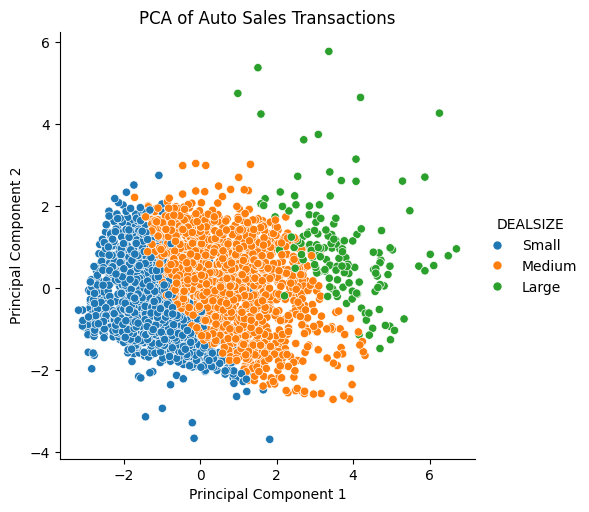

In [81]:
sns.relplot(x = "PC1", y = "PC2", hue = "DEALSIZE", data = pca_df)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Auto Sales Transactions")

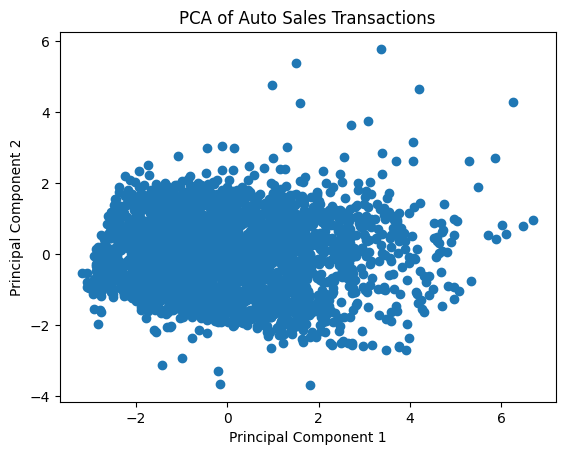

In [73]:
plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Auto Sales Transactions")
plt.show()

In [79]:
#not included

<Axes: ylabel='PRODUCTLINE'>

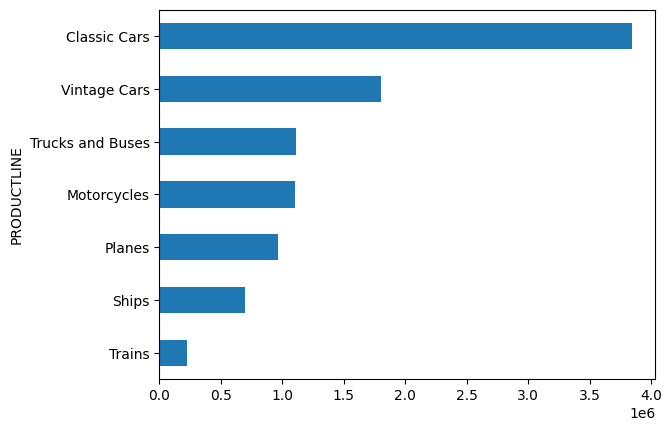

In [78]:
product_sales = df.groupby("PRODUCTLINE")["SALES"].sum().sort_values()
product_sales.plot(kind = "barh")